#  Ice cream data  non-linear

## Loading Dataset

In [73]:
import pandas as pd 

df = pd.read_csv("../datasets/Ice_cream_selling_data_non-linear.csv")
df.head(2)



,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120


## Data cleaning

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [75]:
df.shape

(49, 2)

In [76]:
df.isnull().count()

Temperature (°C)           49
Ice Cream Sales (units)    49
dtype: int64

In [77]:
df.drop_duplicates()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [78]:
df.dtypes

Temperature (°C)           float64
Ice Cream Sales (units)    float64
dtype: object

**Conclusion:** Data is already clean

## Check for the type of data - linear or not


In [79]:
df.corr()*100

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),100.000000,-17.518429
Ice Cream Sales (units),-17.518429,100.000000


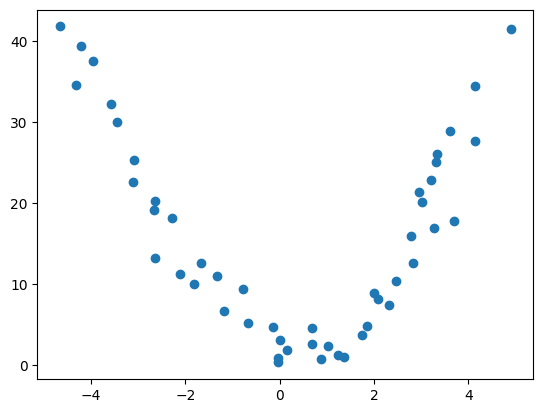

In [80]:
import matplotlib.pyplot as plt

plt.scatter(df['Temperature (°C)'] , df['Ice Cream Sales (units)'],)
plt.show()

## Data Preparation - separating train and test data 

### Separating data into X and y

In [81]:
X = df[['Temperature (°C)']]
                # OR
# X = df.drop('Salary', axis = 1)   
X    #2d

,Temperature (°C)
0,-4.662263
1,-4.316559
2,-4.213985
3,-3.949661
4,-3.578554
5,-3.455712
6,-3.108440
7,-3.081303
8,-2.672461
9,-2.652287


In [82]:
y = df['Ice Cream Sales (units)']  #1d
y

0     41.842986
1     34.661120
2     39.383001
3     37.539845
4     32.284531
5     30.001138
6     22.635401
7     25.365022
8     19.226970
9     20.279679
10    13.275828
11    18.123991
12    11.218294
13    10.012868
14    12.615181
15    10.957731
16     6.689123
17     9.392969
18     5.210163
19     4.673643
20     0.328626
21     0.897603
22     3.165600
23     1.931416
24     2.576782
25     4.625689
26     0.789974
27     2.313806
28     1.292361
29     0.953115
30     3.782570
31     4.857988
32     8.943823
33     8.170735
34     7.412094
35    10.336631
36    15.996620
37    12.568237
38    21.342916
39    20.114413
40    22.839406
41    16.983279
42    25.142082
43    26.104740
44    28.912188
45    17.843957
46    34.530743
47    27.698383
48    41.514822
Name: Ice Cream Sales (units), dtype: float64

### Separating X and y into Training and test data

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### model training - separation of training and test data

In [84]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()  # object of class LinearRegression

model_lr.fit(X_train,y_train)  # but actually we should have given training data (xtrain, ytrain)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [85]:
slope = model_lr.coef_
print(slope)
df.dtypes

[-1.14658686]


Temperature (°C)           float64
Ice Cream Sales (units)    float64
dtype: object

In [86]:
intercept = model_lr.intercept_
intercept

np.float64(17.139213127718417)

**Conclusion:** 
1. **_Slope:_**  - Each feature column has separate slope values
- 

2. **_Intercept:_**
- 

### model prediction and evaluation

#### train data

In [87]:
y_pred_train = model_lr.predict(X_train)
y_pred_train

array([19.56065517, 21.24233581, 14.48074687, 20.20342161, 21.66784265,
       20.70330974, 13.45710289, 13.38982355, 12.40281419, 18.66002185,
       20.18029032, 18.48430086, 16.34946599, 14.75993004, 15.14415197,
       22.48490227, 13.31427684, 14.84683012, 21.10148677, 15.58006978,
       19.76290657, 13.94615622, 22.08852349, 17.17807702, 21.9709127 ,
       13.89235407, 14.30491232, 16.96809126, 13.67551832, 20.17938594,
       17.12934365, 17.91172924, 11.52204795, 17.18066969, 20.67219504,
       13.33704794, 19.04294602, 15.71662948, 13.74539387])

In [88]:
# if error is less model is performing good

#### importing and evaluatng the model using metrics

In [89]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [90]:
r2_score(X_train, y_pred_train)

-41.82599869029424

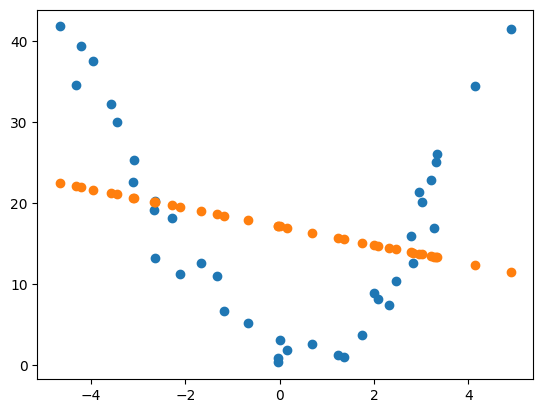

In [91]:
import matplotlib.pyplot as plt

plt.scatter(X_train, y_train)
plt.scatter(X_train, y_pred_train)

#### test data

In [92]:
y_pred_test = model_lr.predict(X_test)
y_pred_test

array([19.2247831 , 12.89218952, 12.39975758, 12.99914196, 18.0259032 ,
       15.96490086, 16.13605851, 16.34394177, 15.0173946 , 17.3107825 ])

In [93]:
error = y_test - y_pred_test
error

13    -9.211915
45     4.951767
47    15.298626
44    15.913046
17    -8.632935
27   -13.651095
26   -15.346085
25   -11.718252
31   -10.159407
19   -12.637140
Name: Ice Cream Sales (units), dtype: float64

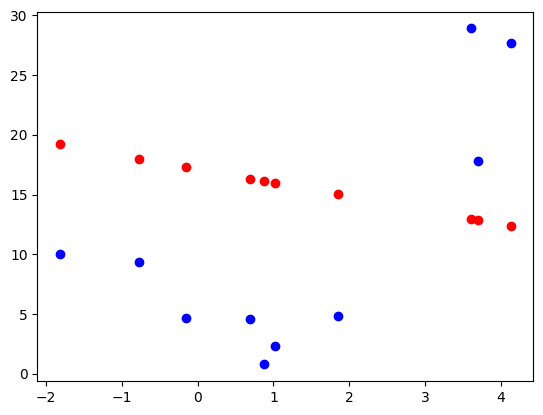

In [94]:
import matplotlib.pyplot as plt 

plt.scatter(X_test, y_test , color="b")
plt.scatter(X_test, y_pred_test, color='red')


#### checking the overfitting/ underfit/ goodfit

In [95]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [96]:
train_r2 = r2_score(y_train, y_pred_train)

test_r2 = r2_score(y_test, y_pred_test)

print("Train R2 :", train_r2)
print("Test R2  :", test_r2)

Train R2 : 0.06579063815950037
Test R2  : -0.5751270190188227


**conclusion: (overfitting / underfitting/ goodfit)**
- train data r2_score = 0.0657 --> 6.5 
- test data r2_score = -0.5751 --> -57
- since model is performing well on both the data(train and test) - model is **underfitting**
